![image-2.png](attachment:image-2.png)
_Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Actividad grupal: Explorando patrones ocultos: Detección de Anomalías en datos
## Objetivos

Mediante este trabajo se pretende que ponga en práctica la aplicación de las técnicas de detección de anomalías. El objetivo es analizar si existen anomalías en el conjunto de datos aplicando técnicas univariantes y multivariantes. Debe detallar los pasos que hay que realizar para detección de valores inusuales.

- 	Entender los métodos media móvil, z-score, Isolation Forest y Local Outlier Factor
- Implementar el código para cada una de estas técnicas y analizar si existen o no anomalía

Descripción de la actividad

Debes realizar la actividad en el Notebook adjunto. Debes ir completando el código solicitado, así como responder a las preguntas que se van realizando.

Tareas que analizar:
- Detección de anomalías.
    - Debes completar el código pedido en este notebook y contestar las preguntas finales.

## Detección de anomalías

Los transformadores juegan un papel muy importante en el sistema eléctrico. Aunque son algunos de los componentes más confiables de la red eléctrica, también son propensos a fallar debido a muchos factores, tanto internos como externos. Podría haber muchos iniciadores que causen una falla en el transformador, pero los que potencialmente pueden conducir a una falla catastrófica son los siguientes:
Falla mecánica
Falla dieléctrica

Contenido
Estos datos se recopilaron a través de dispositivos IoT desde el 25 de junio de 2019 hasta el 14 de abril de 2020 y se actualizaron cada 15 minutos.
El dataset contiene 19352 registros.
Descripción de los parámetros:
Voltaje de corriente:
1. VL1- Fase Línea 1
2. VL2- Fase Línea 2
3. VL3- Fase Línea 3
4. IL1- Línea actual 1
5. IL2- Línea actual 2
6. IL3- Línea actual 3
7. VL12- Línea de tensión 1 2
8. VL23- Línea de tensión 2 3
9. VL31- Línea de tensión 3 1
10. INUT-Corriente neutra

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# Cargar el dataset
file_path = '/content/drive/MyDrive/ColabNotebooks/muinar07_act3_CurrentVoltage.csv'

# Leer el archivo CSV
df = pd.read_csv(file_path)

Mounted at /content/drive


#### ¿Cuántas instancias tiene el dataset?

In [ ]:
# Obtener número de filas y columnas
num_filas, num_columnas = df.shape
print(f"El dataset tiene {num_filas} filas y {num_columnas} columnas.")

El dataset tiene 19352 filas y 11 columnas.


#### ¿Cuál es el tipo de datos predominante en las variables?

In [ ]:
#Inserta acá el código
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19352 entries, 0 to 19351
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DeviceTimeStamp  19352 non-null  object 
 1   VL1              19352 non-null  float64
 2   VL2              19352 non-null  float64
 3   VL3              19352 non-null  float64
 4   IL1              19352 non-null  float64
 5   IL2              19352 non-null  float64
 6   IL3              19352 non-null  float64
 7   VL12             19352 non-null  float64
 8   VL23             19352 non-null  float64
 9   VL31             19352 non-null  float64
 10  INUT             19352 non-null  float64
dtypes: float64(10), object(1)
memory usage: 1.6+ MB


## Variables nulas

#### ¿Tiene este dataset datos faltantes?

¿Tiene este dataset datos faltantes?

#### ¿Es necesario hacer algún tratamiendo adicional sobre los datos?

In [ ]:
### PON AQUÍ TU CÓDIGO EN CASO DE QUE SEA NECESARIO HACER ALGÚN TRATAMIENTO ADICIONAL
df['DeviceTimeStamp'] = pd.to_datetime(df['DeviceTimeStamp'])
df = df.drop_duplicates()
df.set_index('DeviceTimeStamp', inplace=True)
df.head()


,VL1,VL2,VL3,IL1,IL2,IL3,VL12,VL23,VL31,INUT
DeviceTimeStamp,,,,,,,,,,
2019-06-25 13:06:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-06-27 10:49:00,238.7,238.7,238.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-06-27 10:51:00,238.4,238.5,238.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-06-27 10:52:00,239.9,240.0,240.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-06-27 10:53:00,241.1,241.2,241.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Media móvil

In [ ]:
# Vamos a aplicar la técnica de detección de anomalías de Media Móvil sobre la variable INUT

In [ ]:
# Calcula la media móvil
rolling_mean_INUT = df['INUT'].rolling(window=50).mean()

In [ ]:
# Define un umbral para detectar anomalías
residual_INUT = df['INUT'] - rolling_mean_INUT
threshold = 3 * residual_INUT.std()
anomalies = df[np.abs(residual_INUT) > threshold]

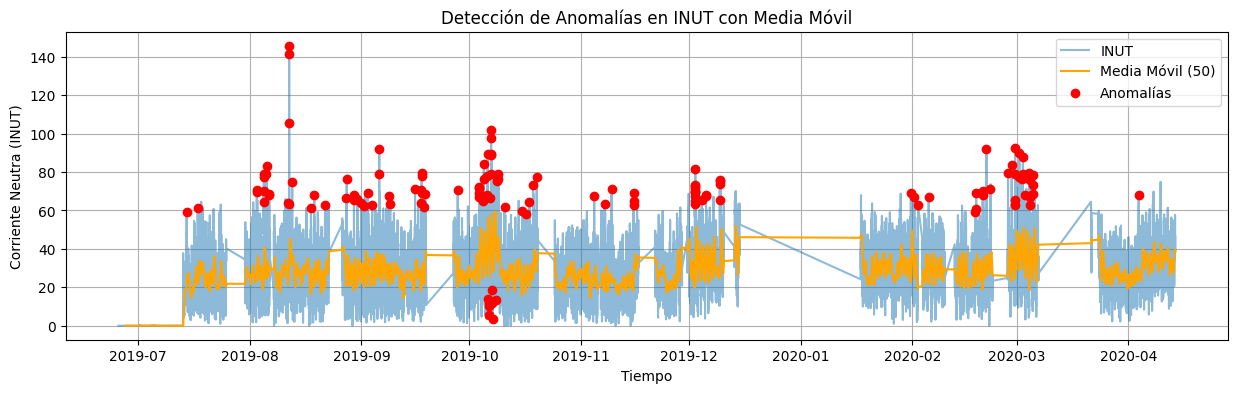

In [ ]:
# Visualiza los resultados
plt.figure(figsize=(15, 4))
plt.plot(df.index, df['INUT'], label='INUT', alpha=0.5)
plt.plot(df.index, rolling_mean_INUT, color='orange', label='Media Móvil (50)')
plt.scatter(anomalies.index, anomalies['INUT'], color='red', label='Anomalías', zorder=5)
plt.title('Detección de Anomalías en INUT con Media Móvil')
plt.xlabel('Tiempo')
plt.ylabel('Corriente Neutra (INUT)')
plt.legend()
plt.grid(True)
plt.show()

#### Z-Score

In [ ]:
# Vamos a aplicar la técnica de detección de anomalías Z-Score
# Pon aquí tu código

In [ ]:
# Define un umbral para detectar anomalías (por ejemplo, 3 desviaciones estándar)
from scipy.stats import zscore

# Aplicar z-score a todas las columnas numéricas
z_scores = np.abs(zscore(df['INUT']))

# Umbral clásico para considerar un punto como anomalía
threshold = 3

# Creamos una máscara booleana para detectar si alguna columna supera el umbral
anomaly_mask = z_scores > threshold

# Extraemos las filas anómalas
anomalies_df = df[anomaly_mask]

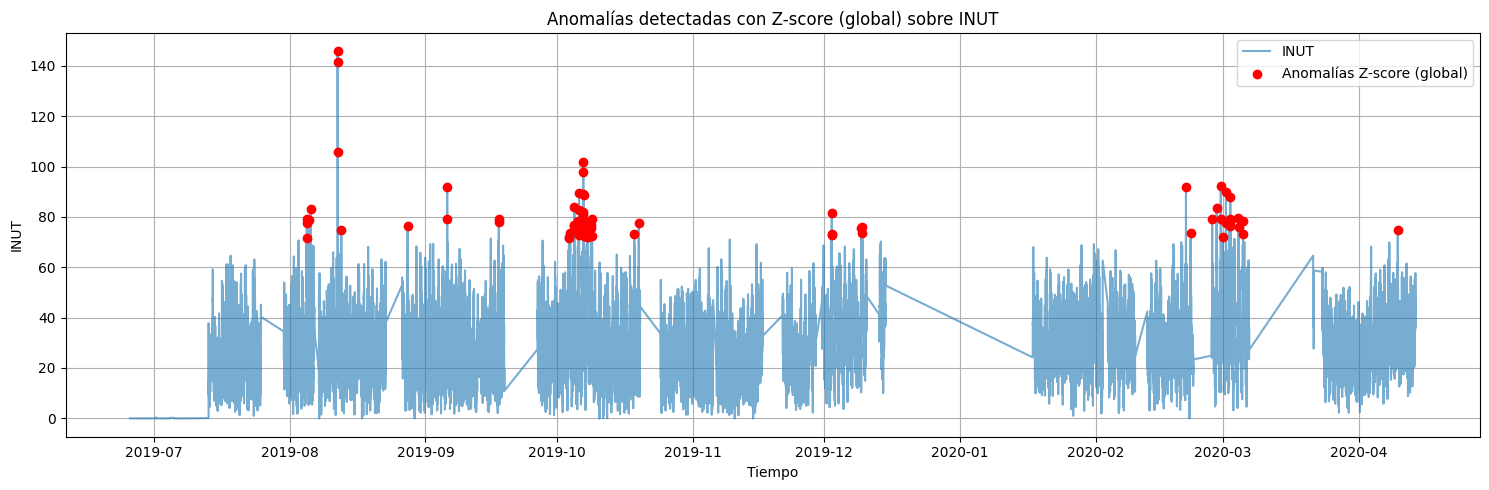

In [ ]:
# Visualiza los resultados
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['INUT'], label='INUT', alpha=0.6)
plt.scatter(anomalies_df.index, anomalies_df['INUT'], color='red', label='Anomalías Z-score (global)', zorder=5)
plt.title('Anomalías detectadas con Z-score (global) sobre INUT')
plt.xlabel('Tiempo')
plt.ylabel('INUT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Isolation Forest

In [ ]:
# Vamos a aplicar la técnica de detección de anomalías de Isolation Forest, configura el parámetro contamination en 5%
# Pon aquí tu código
from sklearn.ensemble import IsolationForest

features = df[['INUT']]

clf_5 = IsolationForest(contamination=0.05, random_state=42)


In [ ]:
# Agrega las columnas de puntaje y si es dato anómalo o no en el dataframe
df['anomalo_si_5'] = clf_5.fit_predict(features)
df['score_si_5'] = clf_5.decision_function(features)
df['es_anomalo_5'] = df['anomalo_si_5'].map({1: 'Normal', -1: 'Anómalo'})

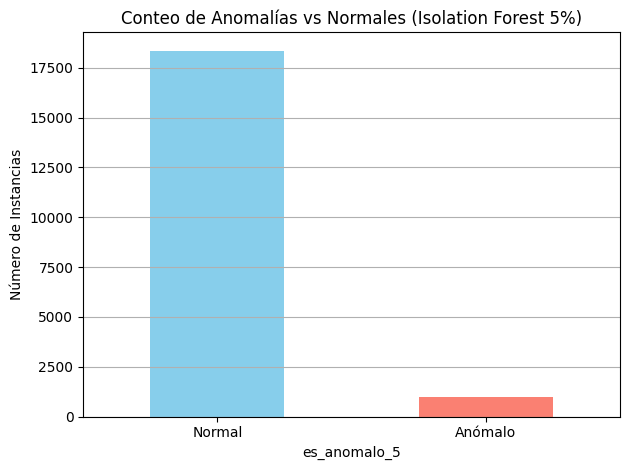

In [ ]:
# Crea un gráfico de barras para mostrar los datos anómalos vs los datos normales
df['es_anomalo_5'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Conteo de Anomalías vs Normales (Isolation Forest 5%)")
plt.ylabel("Número de Instancias")
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

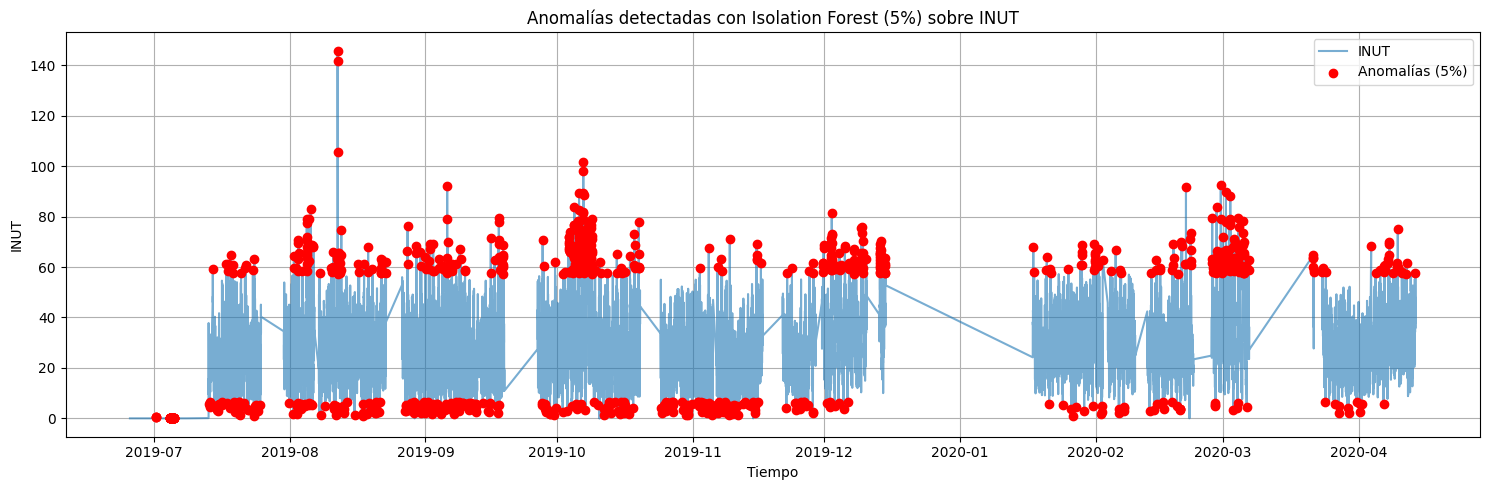

In [ ]:
# Crea un gráfico donde se puedan ver los datos anómalos sobre la variable INUT.
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['INUT'], label='INUT', alpha=0.6)
plt.scatter(df[df['anomalo_si_5'] == -1].index, df[df['anomalo_si_5'] == -1]['INUT'],
            color='red', label='Anomalías (5%)', zorder=5)
plt.title('Anomalías detectadas con Isolation Forest (5%) sobre INUT')
plt.xlabel('Tiempo')
plt.ylabel('INUT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

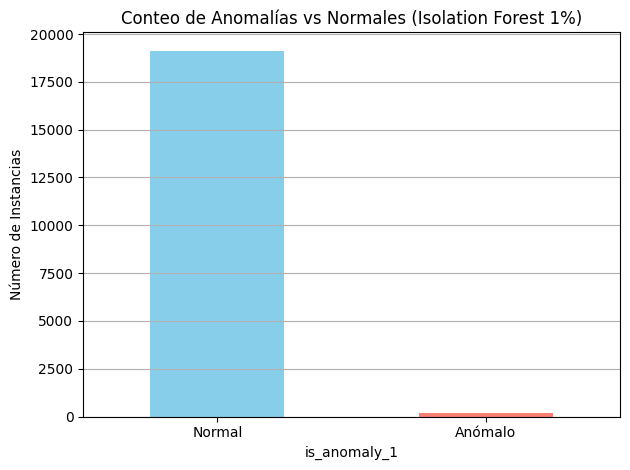

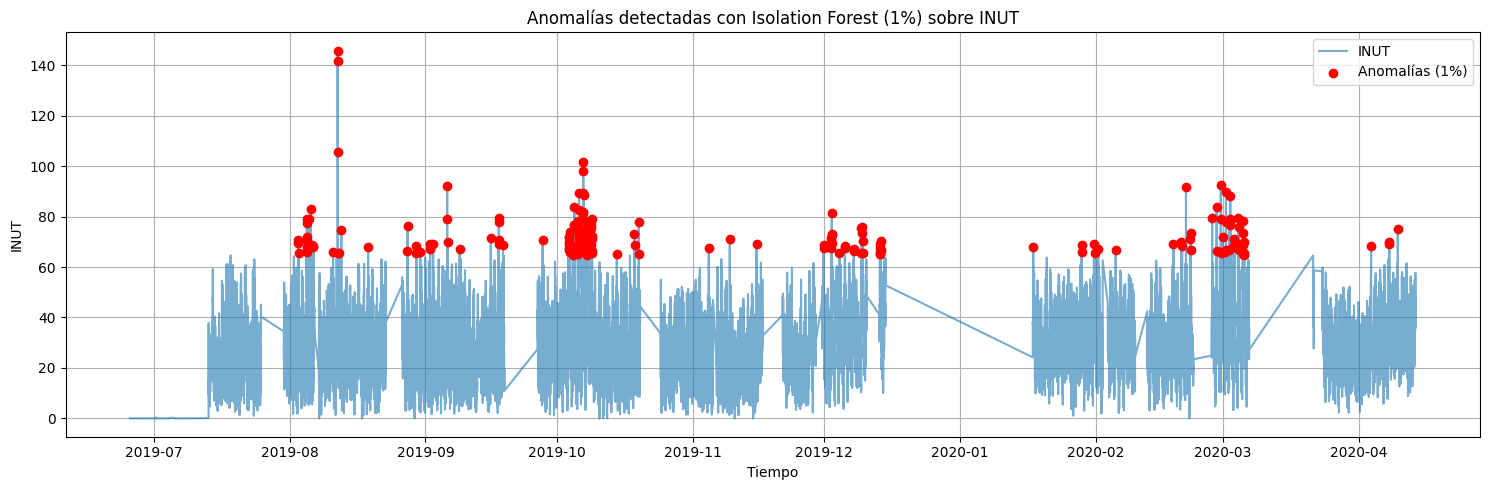

In [ ]:
# Repite los pasos anteriores con el parámetro de contamination en 1%
clf_1 = IsolationForest(contamination=0.01, random_state=42)
df['anomaly_if_1'] = clf_1.fit_predict(features)
df['score_if_1'] = clf_1.decision_function(features)
df['is_anomaly_1'] = df['anomaly_if_1'].map({1: 'Normal', -1: 'Anómalo'})

# Gráfico de barras: cantidad de normales vs anómalos (1%)
df['is_anomaly_1'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Conteo de Anomalías vs Normales (Isolation Forest 1%)")
plt.ylabel("Número de Instancias")
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Gráfico sobre INUT: mostrar anomalías
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['INUT'], label='INUT', alpha=0.6)
plt.scatter(df[df['anomaly_if_1'] == -1].index, df[df['anomaly_if_1'] == -1]['INUT'],
            color='red', label='Anomalías (1%)', zorder=5)
plt.title('Anomalías detectadas con Isolation Forest (1%) sobre INUT')
plt.xlabel('Tiempo')
plt.ylabel('INUT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Local Outlier Factor

In [ ]:
# Vamos a aplicar la técnica de detección de anomalías de Local Outlier Factor
# Pon aquí tu código
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['anomaly_lof'] = lof.fit_predict(features)  # 1 = normal, -1 = anómalo
df['lof_score'] = lof.negative_outlier_factor_
df['is_anomaly_lof'] = df['anomaly_lof'].map({1: 'Normal', -1: 'Anómalo'})

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


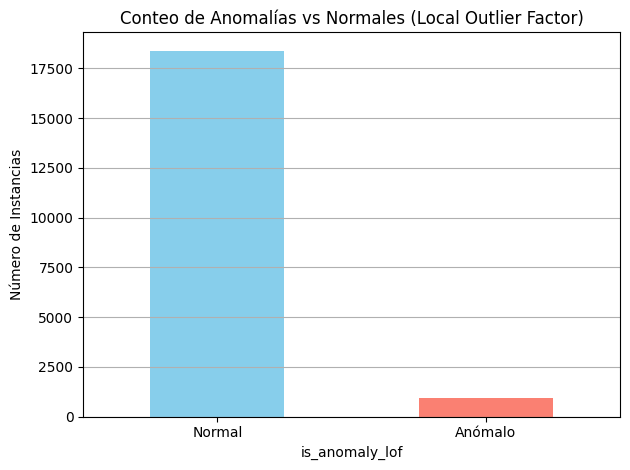

In [ ]:
# Crea un gráfico de barras para mostrar los datos anómalos vs los datos normales
df['is_anomaly_lof'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Conteo de Anomalías vs Normales (Local Outlier Factor)")
plt.ylabel("Número de Instancias")
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

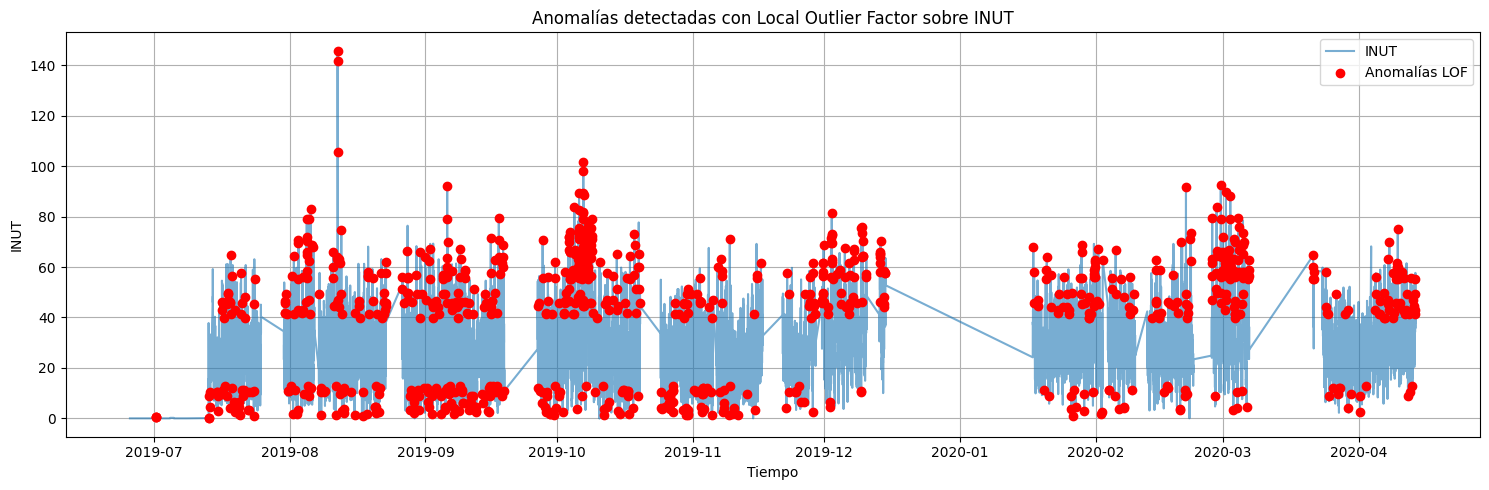

In [ ]:
# Crea un gráfico donde se puedan ver los datos anómalos sobre la variable INUT.
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['INUT'], label='INUT', alpha=0.6)
plt.scatter(df[df['anomaly_lof'] == -1].index,
            df[df['anomaly_lof'] == -1]['INUT'],
            color='red', label='Anomalías LOF', zorder=5)
plt.title("Anomalías detectadas con Local Outlier Factor sobre INUT")
plt.xlabel("Tiempo")
plt.ylabel("INUT")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Análisis

# Realiza un análisis detallado de los resultados obtenidos en cada una de las técnicas aplicadas. Utiliza gráficos o trablas para apoyar tu conclusiones

En este análisis, hemos aplicado distintas técnicas de detección de anomalías sobre la serie temporal de la corriente neutra (INUT). La primera técnica empleada fue una media móvil con ventana de tamaño 50. Esta estrategia suaviza la señal para capturar tendencias locales y luego identifica anomalías como aquellos puntos que se alejan significativamente de dicha media. Visualmente, esto resalta picos o bajadas abruptas respecto al contexto inmediato. Es una técnica sencilla e intuitiva, útil para detectar comportamientos anómalos a corto plazo, pero también susceptible al ruido y a la elección del tamaño de la ventana, que puede ocultar o exagerar ciertos eventos.

Luego aplicamos la detección de anomalías mediante el Z-score global. Esta técnica transforma los valores de INUT en función de su desviación respecto a la media global del conjunto, considerando anómalo cualquier valor que esté a más de tres desviaciones estándar del promedio. Esto permitió detectar outliers extremos de forma rápida, especialmente picos muy altos o muy bajos. Sin embargo, su gran limitación es que no tiene en cuenta la dimensión temporal, y si la serie tiene cambios de comportamiento o estacionalidades, el Z-score puede pasar por alto anomalías locales o marcar como outliers algunos valores que simplemente pertenecen a otro contexto normal.

A continuación, utiizamos el algoritmo Isolation Forest, primero configurado con una tasa de contaminación del 5%. Esta técnica se basa en la idea de que las anomalías son más fáciles de aislar que los puntos normales, ya que suelen estar en zonas más dispersas o extremas del espacio de características. El modelo construye árboles de decisión aleatorios para intentar separar los puntos, y aquellos que requieren menos particiones para ser aislados se consideran más anómalos. Con el 5% de contaminación, el resultado es una detección muy sensible, que permite capturar muchos puntos raros, aunque también se cuela algún falso positivo. Es una estrategia potente cuando no te importa una ligera sobreestimación de anomalías.

En cambio, al repetir la técnica de Isolation Forest pero reduciendo la contaminación al 1%, el modelo se vuelve mucho más conservador. Aquí solo se destacan como anómalos los casos más extremos y evidentes. Es útil cuando se quiere minimizar el número de falsas alarmas, aunque puede dejar fuera algunas anomalías reales que no son tan pronunciadas. Este enfoque refleja bien la tensión entre sensibilidad y especificidad que suele acompañar a la detección de outliers.

Finalmente, aplicamos el algoritmo Local Outlier Factor (LOF), que introduce una perspectiva basada en la densidad local. LOF no se fija tanto en los valores absolutos sino en cuán extraño es un punto respecto a sus vecinos cercanos. Un valor puede no parecer raro globalmente, pero si se encuentra en una zona donde los puntos cercanos tienen un comportamiento muy diferente, se marca como anómalo. Esta técnica es muy útil para detectar outliers contextuales, es decir, aquellos que sólo lo son en un cierto entorno. En el gráfico, LOF resalta muchos puntos distribuidos a lo largo del tiempo, captando cambios sutiles en el patrón local, aunque también puede ser más propenso a marcar como anomalía datos que simplemente forman parte de una transición o de una fluctuación normal.